In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [4]:
# Load yearly demand — drop partial years (2002 starts May, 2026 is incomplete)
df = pd.read_csv('./data/Yearly_Market_Demand_2002-2026.csv')
df = df[(df['Year'] >= 2003) & (df['Year'] <= 2025)].copy()
df['Year'] = df['Year'].astype(int)
df['TWh'] = df['Total_Market_Demand'] / 1e6  # MWh → TWh

print(df[['Year', 'TWh']].to_string())


    Year         TWh
1   2003  157.982144
2   2004  162.925342
3   2005  167.153184
4   2006  162.442513
5   2007  164.491422
6   2008  170.876581
7   2009  154.300535
8   2010  157.360156
9   2011  154.319233
10  2012  155.905911
11  2013  158.542864
12  2014  158.273142
13  2015  159.031052
14  2016  158.174232
15  2017  150.578393
16  2018  155.631773
17  2019  154.455959
18  2020  152.173361
19  2021  150.607860
20  2022  154.593808
21  2023  152.796391
22  2024  158.303840
23  2025  165.511186


In [5]:
# Fit three models on historical data
years = df['Year'].values
twh   = df['TWh'].values
all_years = np.arange(2003, 2051)

X_hist = years.reshape(-1, 1)
X_all  = all_years.reshape(-1, 1)

# 1. Linear regression
lin = LinearRegression().fit(X_hist, twh)
lin_pred = lin.predict(X_all)

# 2. Polynomial degree-2 (captures the decline → recent uptick)
poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly2.fit(X_hist, twh)
poly2_pred = poly2.predict(X_all)

# 3. Holt's exponential smoothing (damped additive trend)
holt = ExponentialSmoothing(twh, trend='add', damped_trend=True,
                            initialization_method='estimated').fit()
holt_hist = holt.fittedvalues
holt_fcast = holt.forecast(2050 - 2025)
holt_pred = np.concatenate([holt_hist, holt_fcast])

print(f"{'Model':<12} {'2030':>8} {'2040':>8} {'2050':>8}")
print("-" * 38)
for name, pred in [('Linear', lin_pred), ('Poly-2', poly2_pred), ('Holt', holt_pred)]:
    idx30 = np.where(all_years == 2030)[0][0]
    idx40 = np.where(all_years == 2040)[0][0]
    idx50 = len(pred) - 1
    print(f"{name:<12} {pred[idx30]:>7.1f}  {pred[idx40]:>7.1f}  {pred[idx50]:>7.1f}")


Model            2030     2040     2050
--------------------------------------
Linear         152.1    148.4    144.7
Poly-2         161.6    176.7    200.7
Holt           154.6    154.2    154.1


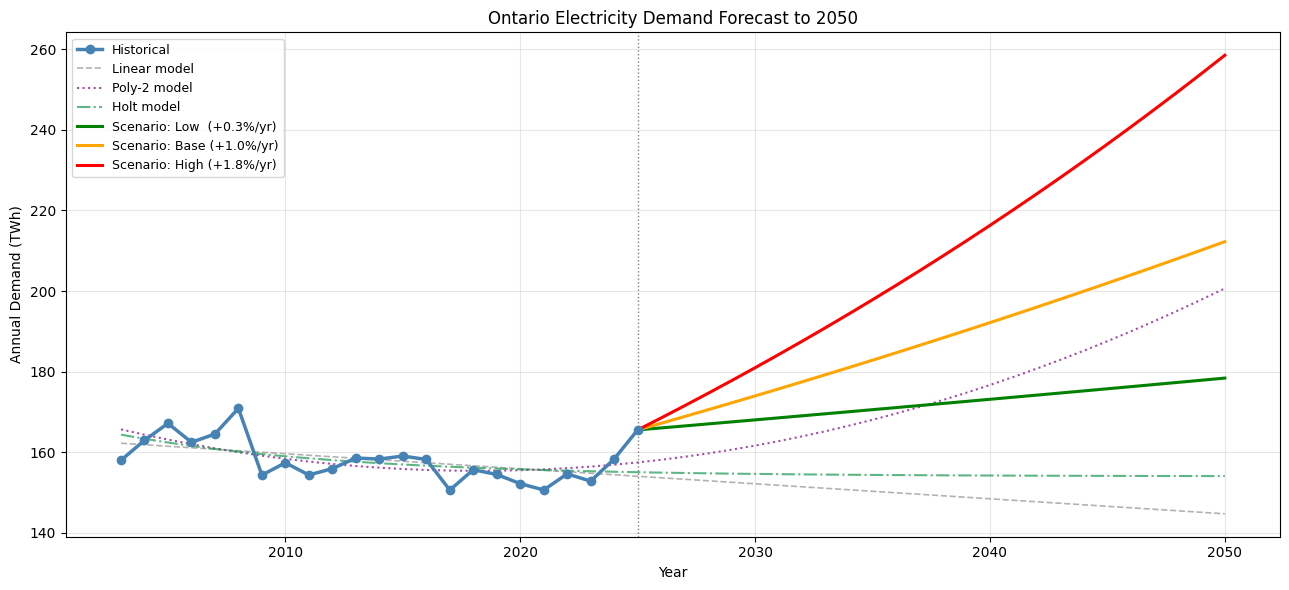

In [6]:
# Scenario forecasts anchored at 2025 actual value
# Growth rates reflect: low=efficiency gains, base=moderate electrification, high=aggressive EVs/heat-pumps/data-centres
base_2025 = df.loc[df['Year'] == 2025, 'TWh'].values[0]
future_years = np.arange(2025, 2051)

scenarios = {
    'Low  (+0.3%/yr)' : 0.003,
    'Base (+1.0%/yr)' : 0.010,
    'High (+1.8%/yr)' : 0.018,
}
colours = {'Low  (+0.3%/yr)': 'green', 'Base (+1.0%/yr)': 'orange', 'High (+1.8%/yr)': 'red'}

fig, ax = plt.subplots(figsize=(13, 6))

# Historical
ax.plot(df['Year'], df['TWh'], 'o-', color='steelblue', linewidth=2.5, label='Historical', zorder=5)

# Model forecasts (dashed, light)
ax.plot(all_years, lin_pred,   '--', color='gray',   alpha=0.6, linewidth=1.2, label='Linear model')
ax.plot(all_years, poly2_pred, ':',  color='purple',  alpha=0.7, linewidth=1.5, label='Poly-2 model')
ax.plot(all_years, holt_pred,  '-.', color='#1a9850', alpha=0.7, linewidth=1.5, label='Holt model')

# Scenario bands
for label, rate in scenarios.items():
    vals = base_2025 * (1 + rate) ** (future_years - 2025)
    ax.plot(future_years, vals, linewidth=2.2, color=colours[label], label=f'Scenario: {label}')

ax.axvline(2025, color='black', linestyle=':', alpha=0.5, linewidth=1)
ax.set(title='Ontario Electricity Demand Forecast to 2050',
       xlabel='Year', ylabel='Annual Demand (TWh)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [7]:
# Summary table: scenario values at key years
rows = []
for label, rate in scenarios.items():
    row = {'Scenario': label}
    for yr in [2030, 2035, 2040, 2045, 2050]:
        row[str(yr)] = round(base_2025 * (1 + rate) ** (yr - 2025), 1)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Scenario')
print(f"\nBase year (2025): {base_2025:.1f} TWh\n")
print(summary.to_string())



Base year (2025): 165.5 TWh

                  2030   2035   2040   2045   2050
Scenario                                          
Low  (+0.3%/yr)  168.0  170.5  173.1  175.7  178.4
Base (+1.0%/yr)  174.0  182.8  192.2  202.0  212.3
High (+1.8%/yr)  181.0  197.8  216.3  236.5  258.5


Generation by Year (TWh):
 Year  Total_Generation_TWh
 2005             164.14700
 2006             159.22100
 2007             162.88164
 2008             158.05113
 2009             145.87407
 2010             135.41292
 2011             148.02805
 2012             147.19514
 2013             154.56092
 2014             156.16848
 2015             157.44655
 2016             157.03824
 2017             152.64161
 2018             156.12314
 2019             155.19080
 2020             157.75230
 2021             152.85159
 2022             157.95370
 2023             158.13533
 2024             158.45826
 2025             154.60086
 2026             154.23492
 2027             149.82326
 2028             152.87957
 2029             151.15226
 2030             161.25486
 2031             171.14543
 2032             185.38129
 2033             187.14483
 2034             196.30639
 2035             201.72387
 2036             214.64222
 2037             222.47407
 2038             233.

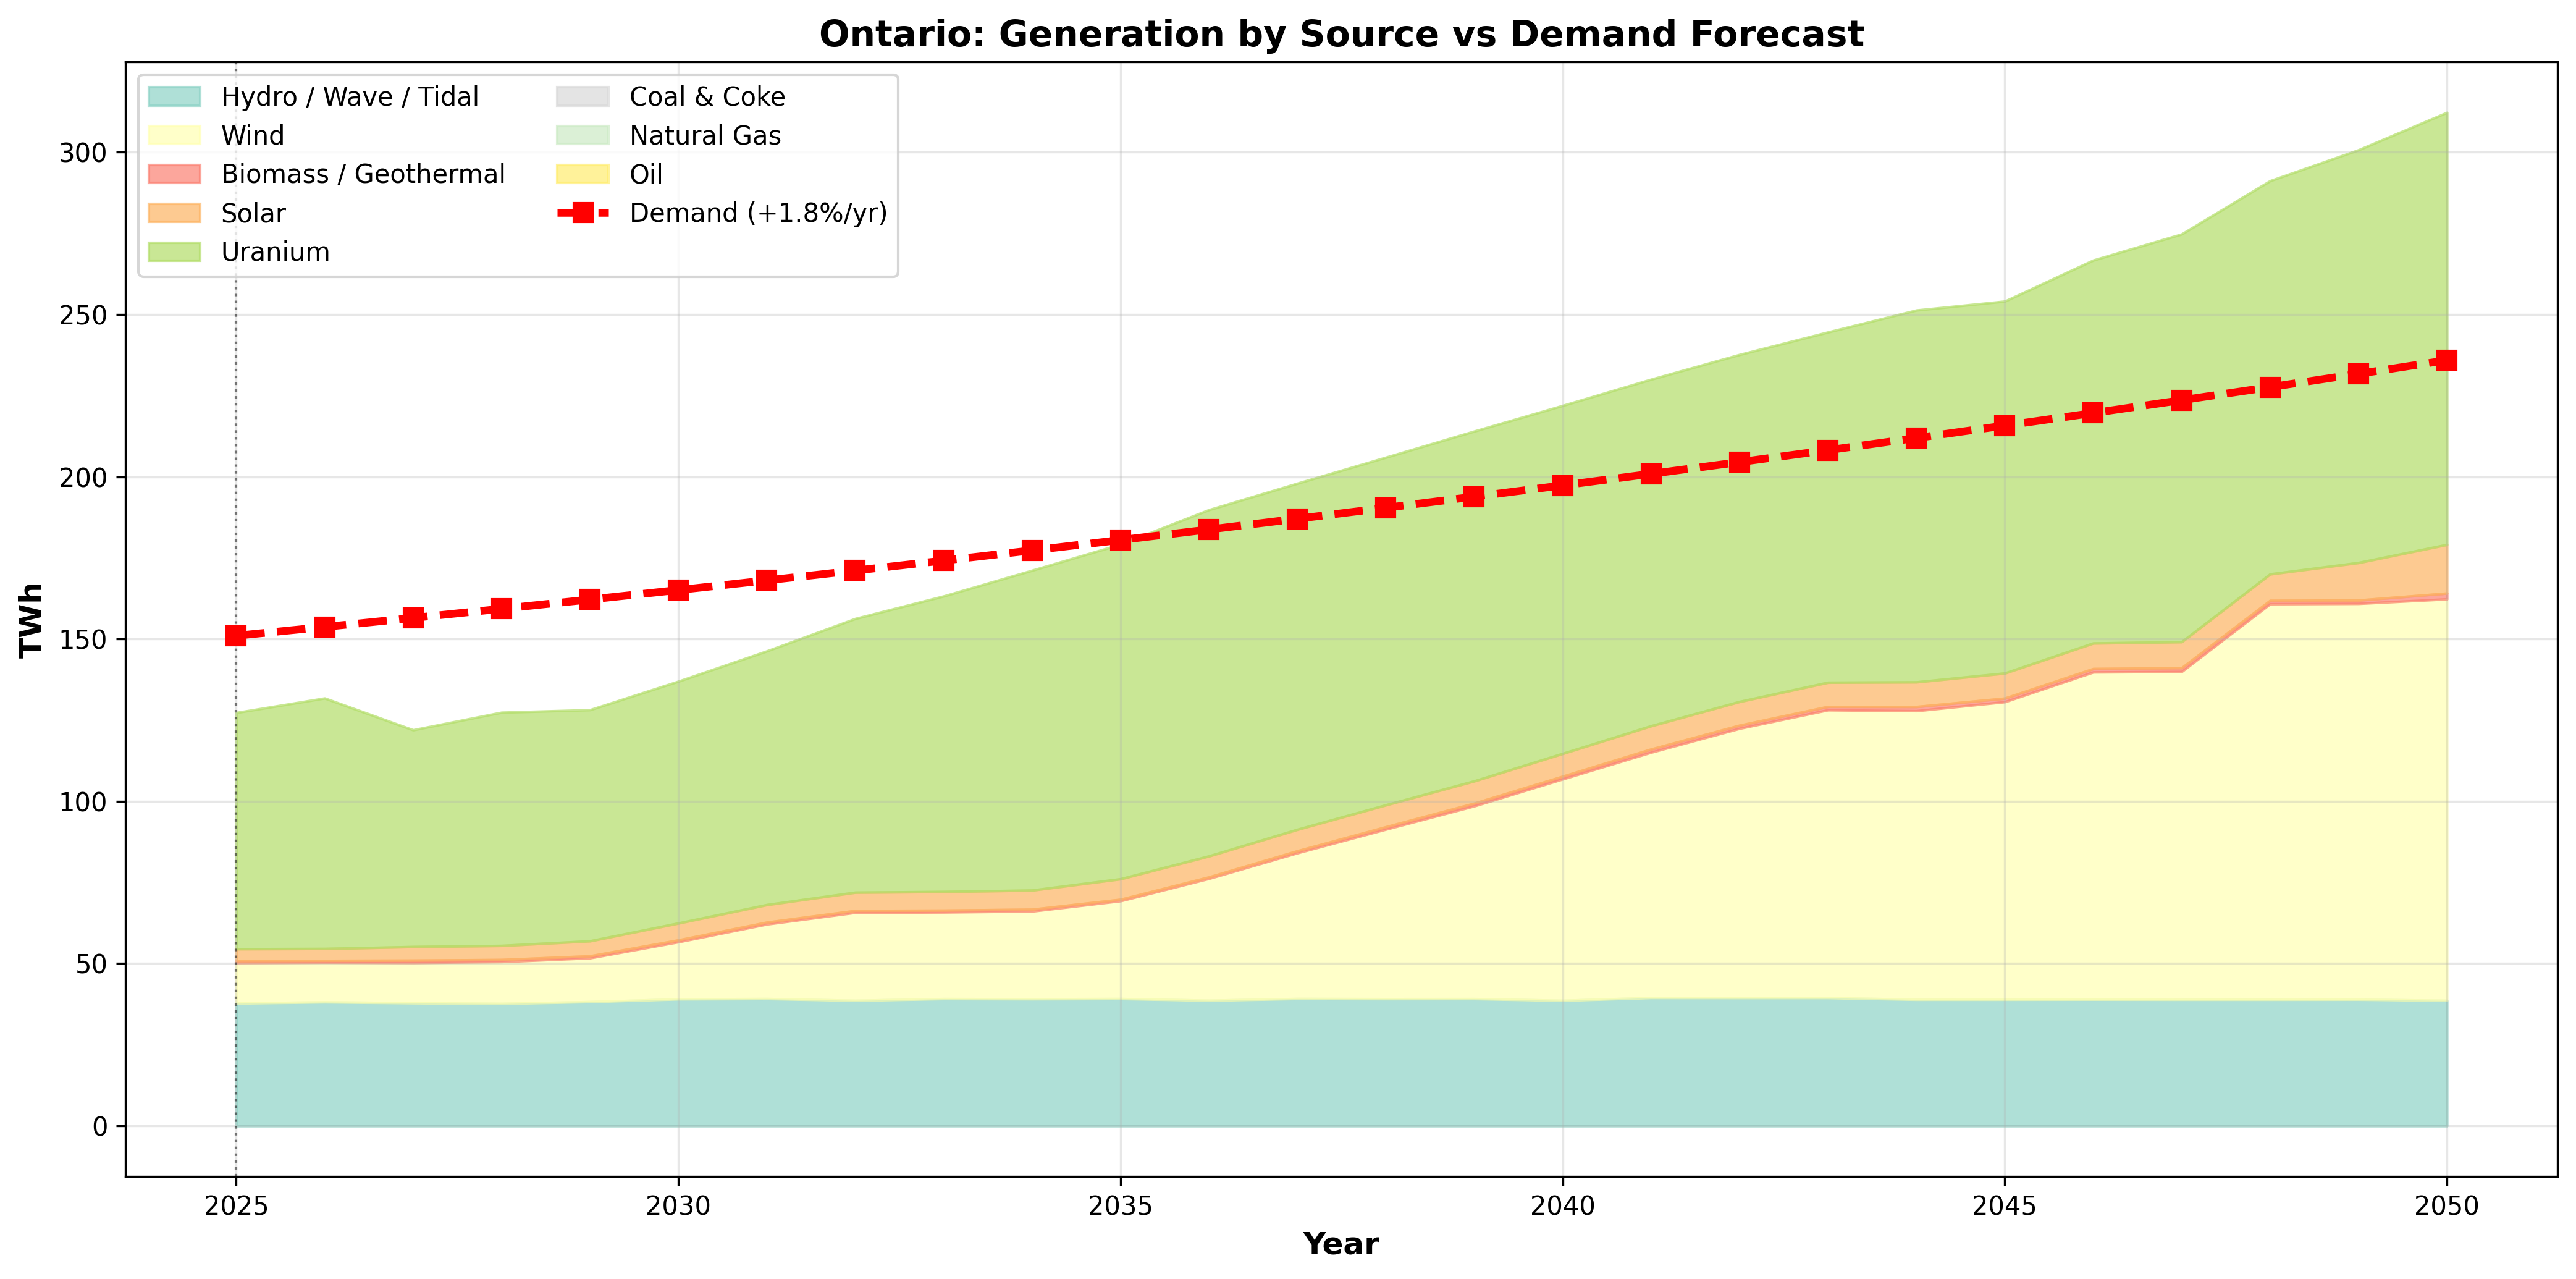


✓ Stacked generation forecast chart saved


In [ ]:
# Load generation forecast from file
gen_df = pd.read_excel('./data/Electricity_Generation_By_Source_Ontario.xlsx')

# Set first column as index (source names)
gen_df_indexed = gen_df.set_index(gen_df.columns[0])
sources = gen_df_indexed.index.tolist()
years_gen = gen_df_indexed.columns.astype(int).tolist()

# Calculate total generation for each year (sum across all sources)
total_gen_by_year = gen_df_indexed.sum(axis=0)
total_gen_gwh = total_gen_by_year.values
total_gen_twh = total_gen_gwh / 1000

print("Generation by Year (TWh):")
gen_summary = pd.DataFrame({
    'Year': years_gen,
    'Total_Generation_TWh': total_gen_twh
})
print(gen_summary.to_string(index=False))

# Create demand forecast: 151 TWh in 2026, 263 TWh in 2050
# Calculate required growth rate
demand_2026 = 151  # TWh
demand_2050 = 263  # TWh
years_diff = 2050 - 2026
growth_rate = (demand_2050 / demand_2026) ** (1 / years_diff) - 1

print(f"Demand Profile: {demand_2026} TWh in 2026 → {demand_2050} TWh in 2050")
print(f"Required annual growth rate: {growth_rate * 100:.2f}%")

future_years = np.arange(2026, 2051)
demand_forecast_df = pd.DataFrame({
    'Year': future_years,
    'Total_Demand_TWh': demand_2026 * (1 + growth_rate) ** (future_years - 2026)
})

print(f"\nDemand Forecast (2026-2050):")
print(demand_forecast_df.to_string(index=False))

# Align generation and demand
gen_forecast_df = pd.DataFrame({
    'Year': years_gen,
    'Total_Generation_TWh': total_gen_twh
})

# Merge on available years (where both have data)
comparison_forecast = gen_forecast_df.merge(demand_forecast_df, on='Year', how='outer')
comparison_forecast = comparison_forecast.sort_values('Year')
comparison_forecast['Gap_TWh'] = comparison_forecast['Total_Generation_TWh'] - comparison_forecast['Total_Demand_TWh']

print("\n\nGeneration vs Demand Forecast:")
print("(Demand: +1.8%/yr)")
print(comparison_forecast.to_string(index=False))

# Create comparison graph with stacked generation by source
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

# Plot only complete data points
valid_data = comparison_forecast.dropna(subset=['Total_Generation_TWh', 'Total_Demand_TWh'])

# Get generation by source for valid years
gen_by_source_dict = {}
for source in sources:
    gen_by_source_dict[source] = []

# Convert years_gen to list of integers for matching
years_gen_int = [int(y) for y in years_gen]

for year in valid_data['Year']:
    year_int = int(year)
    if year_int in years_gen_int:
        for source in sources:
            # Access by position to avoid column name issues
            col_idx = years_gen_int.index(year_int)
            value = gen_df_indexed.iloc[gen_df_indexed.index.tolist().index(source), col_idx]
            gen_by_source_dict[source].append(value / 1000)  # Convert to TWh
    else:
        for source in sources:
            gen_by_source_dict[source].append(np.nan)

# Create stacked area chart for generation by source
colors = plt.cm.Set3(np.linspace(0, 1, len(sources)))
bottom = np.zeros(len(valid_data))

for idx, source in enumerate(sources):
    values = np.array(gen_by_source_dict[source])
    ax.fill_between(valid_data['Year'], bottom, bottom + values, 
                    label=source, alpha=0.7, color=colors[idx])
    bottom = bottom + values

# Plot demand line on top
ax.plot(valid_data['Year'], valid_data['Total_Demand_TWh'], 
        marker='s', linewidth=3, markersize=7, label=f'Demand ({growth_rate*100:.2f}%/yr)', 
        color='red', linestyle='--', zorder=10)

ax.axvline(2025, color='black', linestyle=':', alpha=0.5, linewidth=1)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('TWh', fontsize=12, fontweight='bold')
ax.set_title('Ontario: Generation by Source vs Demand Forecast', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/Generation_vs_Demand_Forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Stacked generation forecast chart saved")
